In [ ]:
#cotton
!wget 'https://data.mendeley.com/public-api/zip/b3jy2p6k8w/download/2'
#rice
!wget 'https://data.mendeley.com/public-api/zip/hx6f852hw4/download/2'

--2026-07-14 17:51:58--  https://data.mendeley.com/public-api/zip/b3jy2p6k8w/download/2
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/b3jy2p6k8w-2.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEFIaCWV1LXdlc3QtMSJIMEYCIQDLBq%2BMKZ%2F0F%2Bm2yoQ8eEP5EBHFBaa7rL2P9QUPrKaljgIhANA%2FdvZkP7CzMKbhRpzcQ%2F0njVV8QhkSJVdUsH0reTZnKowFCBsQBBoMMzY3MTQ3MzgzODI1IgxRnZgBNprtlZrMm0Qq6QRp2qYY6Nti12%2F%2BQ5hGuxnmKICzsapoUcNrghlcDCa6YTP95IM6khqVSXOX7WhtMdc911rDCVKnEhg9r%2BwrPYB3Iy7LB4FPlKx0bh3kNJk8RdIp%2FpBydWf7MXd3psrlxOX3ovTM%2BvuCbcZFxajCa1F%2F5hsMfF9ym%2BJIHYVrVcNiOwygWHNBUvR7MnG9dtRGWaVVhQsO7IRjHKjnIKD2UPdbHEAHZaXFl4f9pA2czxWDLJYpmTNf%2BfhUIdtJXNgpPp3zJA2dbODaTFJviVXea%2BSCEglVMmU8FTTEiX9ONc%2Fv6yWSzHKt8A6An1VcjkYlTqC98jbXF1fUPDRw29REfwsVy305o5UcLqEQaXjrkMd7d1OZ

In [ ]:
import zipfile
import os
import shutil

def unzip_recursively(path):
    """Recursively unzips all zip files within a given path."""
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.zip'):
                zip_filepath = os.path.join(root, file)
                target_dir = os.path.join(root, os.path.splitext(file)[0])
                print(f"Extracting {zip_filepath} to {target_dir}/")
                os.makedirs(target_dir, exist_ok=True)
                try:
                    with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
                        zip_ref.extractall(target_dir)
                    os.remove(zip_filepath) # Remove the zip file after extraction
                    # Recursively call on the newly extracted directory
                    unzip_recursively(target_dir)
                except zipfile.BadZipFile:
                    print(f"Warning: {zip_filepath} is a bad zip file, skipping.")

In [ ]:
# Initial unzipping of the main downloaded files
cotton_zip_file = '2'
rice_zip_file = '2.1'

cotton_target_dir = 'cotton_data'
rice_target_dir = 'rice_data'

# Ensure clean directories for extraction
shutil.rmtree(cotton_target_dir, ignore_errors=True)
shutil.rmtree(rice_target_dir, ignore_errors=True)
os.makedirs(cotton_target_dir, exist_ok=True)
os.makedirs(rice_target_dir, exist_ok=True)

print(f"Unzipping {cotton_zip_file} to {cotton_target_dir}/")
with zipfile.ZipFile(cotton_zip_file, 'r') as zip_ref:
    zip_ref.extractall(cotton_target_dir)
os.remove(cotton_zip_file)

print(f"Unzipping {rice_zip_file} to {rice_target_dir}/")
with zipfile.ZipFile(rice_zip_file, 'r') as zip_ref:
    zip_ref.extractall(rice_target_dir)
os.remove(rice_zip_file)

print("Initial unzipping complete. Now performing recursive unzipping...")
unzip_recursively(cotton_target_dir)
unzip_recursively(rice_target_dir)
print("Recursive unzipping complete.")

Unzipping 2 to cotton_data/
Unzipping 2.1 to rice_data/
Initial unzipping complete. Now performing recursive unzipping...
Extracting cotton_data/SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection/Augmented Dataset.zip to cotton_data/SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection/Augmented Dataset/
Extracting cotton_data/SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection/Original Dataset.zip to cotton_data/SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection/Original Dataset/
Extracting rice_data/Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images.zip to rice_data/Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/
Extracting rice_data/Rice Leaf Bacterial and Fungal Disease Dataset/Original/Original Images.zip to rice_data/Rice Leaf Bacterial and Fungal Disease Dataset/Original/Original Images/
Recursive unzipping complete.


### Final Directory Structure for Cotton Data

In [ ]:
def print_dir_tree(startpath):
    print(f"\nDirectory tree for: {startpath}")
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

print_dir_tree(cotton_target_dir)


Directory tree for: cotton_data
cotton_data/
    SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection/
        Augmented Dataset/
            Augmented Dataset/
                Bacterial Blight/
                    augmented_Bacterial Blight0738.jpg
                    augmented_Bacterial Blight0698.jpg
                    augmented_Bacterial Blight0645.jpg
                    augmented_Bacterial Blight0141.jpg
                    augmented_Bacterial Blight0661.jpg
                    augmented_Bacterial Blight0190.jpg
                    augmented_Bacterial Blight0714.jpg
                    augmented_Bacterial Blight0891.jpg
                    augmented_Bacterial Blight0003.jpg
                    augmented_Bacterial Blight1000.jpg
                    augmented_Bacterial Blight0799.jpg
                    augmented_Bacterial Blight0241.jpg
                    augmented_Bacterial Blight0537.jpg
                    augmented_Bacterial Blight0002.jpg
                

### Final Directory Structure for Rice Data

In [ ]:
print_dir_tree(rice_target_dir)


Directory tree for: rice_data
rice_data/
    Rice Leaf Bacterial and Fungal Disease Dataset/
        Augmented/
            Augmented Images/
                Augmented Images/
                    Healthy Rice Leaf/
                        augmented_image_131.jpg
                        augmented_image_470.jpg
                        augmented_image_154.jpg
                        augmented_image_94.jpg
                        augmented_image_342.jpg
                        augmented_image_467.jpg
                        augmented_image_394.jpg
                        augmented_image_297.jpg
                        augmented_image_308.jpg
                        augmented_image_137.jpg
                        augmented_image_103.jpg
                        augmented_image_330.jpg
                        augmented_image_17.jpg
                        augmented_image_222.jpg
                        augmented_image_81.jpg
                        augmented_image_255.jpg
                   

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install timm matplotlib seaborn pytorch-gradcam

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 78.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-gradcam: filename=pytorch_gradcam-0.2.1-py3-none-any.whl size=5249 sha256=973f84047cf38a36d539c28c2c25bcc5389f989e2744be22c680f9e2fb6048c3
  Stored in directory: /root/.cache/pip/wheels/b3/37/60/ab0eb271797fc9bf2a8b6edd8e550f2ee0857031e4cc0e2509
Successfully built pytorch-gradcam


### Step 1: Organize Data for Binary Classification

Before we can train a model, we need to organize the data into a structure suitable for `ImageFolder`. We'll create two main directories, `main_dataset/cotton` and `main_dataset/rice`, and copy all respective images into them, flattening their original subfolder structure. This will create a clean binary classification dataset.

In [ ]:
import os
import shutil

# Define target directories
base_output_dir = 'main_dataset'
cotton_output_dir = os.path.join(base_output_dir, 'cotton')
rice_output_dir = os.path.join(base_output_dir, 'rice')

# Create clean output directories
shutil.rmtree(base_output_dir, ignore_errors=True)
os.makedirs(cotton_output_dir, exist_ok=True)
os.makedirs(rice_output_dir, exist_ok=True)

# Source directories from previous unzipping
cotton_source_root = 'cotton_data'
rice_source_root = 'rice_data'

print("Copying cotton images...")
# Iterate through all cotton subdirectories and copy images
for root, _, files in os.walk(cotton_source_root):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            shutil.copy(os.path.join(root, file), cotton_output_dir)

print("Copying rice images...")
# Iterate through all rice subdirectories and copy images
for root, _, files in os.walk(rice_source_root):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            shutil.copy(os.path.join(root, file), rice_output_dir)

print("Data organization complete. Displaying final structure:")

def print_dir_tree(startpath):
    print(f"\nDirectory tree for: {startpath}")
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

print_dir_tree(base_output_dir)

# Count images to verify
num_cotton_images = len(os.listdir(cotton_output_dir))
num_rice_images = len(os.listdir(rice_output_dir))
print(f"\nNumber of cotton images: {num_cotton_images}")
print(f"Number of rice images: {num_rice_images}")

Streaming output truncated to the last 5000 lines.
        augmented_Leaf Redding0909.jpg
        augmented_Curl Virus0735.jpg
        augmented_Herbicide Growth Damage0418.jpg
        LR00472.jpg
        LHJ00182.jpg
        augmented_Leaf Hopper Jassids0302.jpg
        augmented_Leaf Redding0900.jpg
        LR00387.jpg
        augmented_Leaf Variegation0343.jpg
        augmented_Curl Virus0638.jpg
        HGD00205.jpg
        augmented_Bacterial Blight0987.jpg
        augmented_Herbicide Growth Damage0933.jpg
        augmented_Herbicide Growth Damage0045.jpg
        augmented_Leaf Redding0211.jpg
        augmented_Leaf Hopper Jassids0151.jpg
        augmented_Leaf Variegation0550.jpg
        LHJ00210.jpg
        augmented_Leaf Hopper Jassids0281.jpg
        augmented_Leaf Variegation0574.jpg
        augmented_Leaf Hopper Jassids0622.jpg
        LV00004.jpg
        augmented_Leaf Hopper Jassids0540.jpg
        augmented_Leaf Redding0237.jpg
        augmented_Healthy Leaf0206.jpg
     

### Step 2: Prepare DataLoaders

We need to define transformations for our images (resizing, normalization, data augmentation), create a dataset using `ImageFolder`, and then split it into training, validation, and test sets. Finally, we'll create `DataLoader` objects for each set.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define image transformations
# Data augmentation and normalization for training
# Just normalization for validation and testing
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create ImageFolder dataset
dataset = datasets.ImageFolder(base_output_dir, data_transforms['train'])

# Get class names
class_names = dataset.classes
print(f"Classes: {class_names}")
print(f"Class to index mapping: {dataset.class_to_idx}")

# Split dataset into training, validation, and test sets
total_size = len(dataset)
train_size = int(0.7 * total_size)  # 70% for training
val_size = int(0.15 * total_size) # 15% for validation
test_size = total_size - train_size - val_size # 15% for testing

print(f"Total images: {total_size}")
print(f"Train images: {train_size}")
print(f"Validation images: {val_size}")
print(f"Test images: {test_size}")

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Apply appropriate transforms to val and test sets
# Note: ImageFolder already applies transform, need to override for val/test splits
# A more robust way would be to create separate ImageFolder instances for each split
# However, for simplicity here, we'll assume the random_split elements will inherit the transform
# This is a common point of error: random_split returns subsets of the original dataset, retaining its transform.
# For proper validation/test transforms, separate ImageFolder instances are usually preferred.

# Corrected approach: Create separate datasets with respective transforms
train_dataset_corrected = datasets.ImageFolder(base_output_dir, data_transforms['train'])
val_dataset_corrected = datasets.ImageFolder(base_output_dir, data_transforms['val'])
test_dataset_corrected = datasets.ImageFolder(base_output_dir, data_transforms['test'])

# Re-split with the corrected datasets
train_indices = train_dataset.indices
val_indices = val_dataset.indices
test_indices = test_dataset.indices

train_subset = torch.utils.data.Subset(train_dataset_corrected, train_indices)
val_subset = torch.utils.data.Subset(val_dataset_corrected, val_indices)
test_subset = torch.utils.data.Subset(test_dataset_corrected, test_indices)

# Create DataLoaders
batch_size = 32
num_workers = 2 # Adjust based on your system's capabilities

dataloaders = {
    'train': DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers),
    'val': DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers),
    'test': DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
}

dataset_sizes = {
    'train': len(train_subset),
    'val': len(val_subset),
    'test': len(test_subset)
}

print(f"\nDataLoader sizes: {dataset_sizes}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Classes: ['cotton', 'rice']
Class to index mapping: {'cotton': 0, 'rice': 1}
Total images: 11767
Train images: 8236
Validation images: 1765
Test images: 1766

DataLoader sizes: {'train': 8236, 'val': 1765, 'test': 1766}
Using device: cuda:0


### Step 3: Load and Modify EfficientNet Model

We will use `timm` to load a pre-trained DenseNet121 model. Since we are doing binary classification, we need to modify the final fully connected layer to output 2 classes.

In [ ]:
import timm
import torch.nn as nn

# Load pre-trained DenseNet121 model
model = timm.create_model('densenet121', pretrained=True)

# Modify the classifier for our specific task
num_classes = len(class_names) # Should be 2 (cotton, rice)

# DenseNet121 typically has a 'classifier' attribute for the final layer
# Replace the classifier layer
model.classifier = nn.Linear(model.classifier.in_features, num_classes)

# Move model to the device
model = model.to(device)

print("DenseNet121 model loaded and modified for binary classification.")
print(f"Model is on device: {next(model.parameters()).device}")

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

DenseNet121 model loaded and modified for binary classification.
Model is on device: cuda:0


### Step 4: Train the Model

Now we will train our modified EfficientNet model. We'll define the optimizer, loss function, and a learning rate scheduler. The training loop will iterate through epochs, performing forward and backward passes, and updating model weights.

### Best Practices for Efficient Training and Realistic Accuracy

To ensure both efficient training and realistic accuracy, consider the following:

1.  **Data Quality and Quantity:**
    *   **Clean Data:** Ensure your dataset is free of errors, inconsistencies, and mislabeled images.
    *   **Sufficient Data:** Deep learning models require a large amount of data. If your original dataset is small, data augmentation (as applied in Step 2) is crucial.
    *   **Representative Data:** Make sure your training, validation, and test sets are representative of the real-world data the model will encounter.

2.  **Model Architecture:**
    *   **Pre-trained Models (Transfer Learning):** Using pre-trained models (like DenseNet121) on large datasets (e.g., ImageNet) and fine-tuning them for your specific task is highly effective. These models have already learned rich feature representations.
    *   **Appropriate Model Size:** Avoid overly complex models for simple tasks, as they can overfit and be slow to train. For more complex tasks, larger models might be necessary, but always start with a reasonably sized model.

3.  **Hyperparameter Tuning:**
    *   **Learning Rate:** One of the most critical hyperparameters. Use a learning rate scheduler (like `StepLR` you've already implemented) to dynamically adjust it during training.
    *   **Batch Size:** Affects training speed and model convergence. Larger batch sizes can be faster but might lead to poorer generalization. Experiment to find an optimal balance.
    *   **Number of Epochs:** Train long enough for the model to converge, but not so long that it overfits. Early stopping (based on validation performance) is a good practice.

4.  **Regularization Techniques:**
    *   **Dropout:** Randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting.
    *   **Weight Decay (L2 Regularization):** Adds a penalty to the loss function that is proportional to the square of the magnitude of weights, discouraging large weights.
    *   **Data Augmentation:** (Already in place) Crucial for expanding the effective size of your dataset and making the model more robust to variations.

5.  **Optimization Strategies:**
    *   **Optimizer Choice:** Adam (currently used) is a popular and generally robust optimizer. Others like SGD with momentum can also be effective.
    *   **Gradient Clipping:** Prevents exploding gradients in deep networks.

6.  **Monitoring and Evaluation:**
    *   **Validation Set:** Crucial for monitoring model performance during training and tuning hyperparameters. Always evaluate your model on a separate, unseen validation set.
    *   **Loss and Accuracy Curves:** Plotting training and validation loss/accuracy over epochs (as we will do next) helps diagnose overfitting, underfitting, and convergence issues.
    *   **Test Set:** Use the test set *only once* at the very end to get an unbiased estimate of your model's generalization performance.

In [ ]:
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm.notebook import tqdm # Import tqdm for progress bars

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Lists to store training history
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data with a progress bar
            for inputs, labels in tqdm(dataloaders[phase], desc=f'{phase} Epoch {epoch}'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Store history
            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item()) # .item() to get scalar from tensor
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

            # deep copy the model if it's the best validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_losses, train_accs, val_losses, val_accs

# Start training
model, train_losses, train_accs, val_losses, val_accs = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

Epoch 0/9
----------


train Epoch 0:   0%|          | 0/258 [00:00<?, ?it/s]

train Loss: 0.0604 Acc: 0.9803


val Epoch 0:   0%|          | 0/56 [00:00<?, ?it/s]

val Loss: 0.0560 Acc: 0.9830

Epoch 1/9
----------


...

val Loss: 0.0010 Acc: 1.0000

Epoch 9/9
----------


train Epoch 9:   0%|          | 0/258 [00:00<?, ?it/s]

train Loss: 0.0021 Acc: 0.9995


val Epoch 9:   0%|          | 0/56 [00:00<?, ?it/s]

val Loss: 0.0005 Acc: 1.0000

Training complete in 22m 54s
Best val Acc: 1.0000


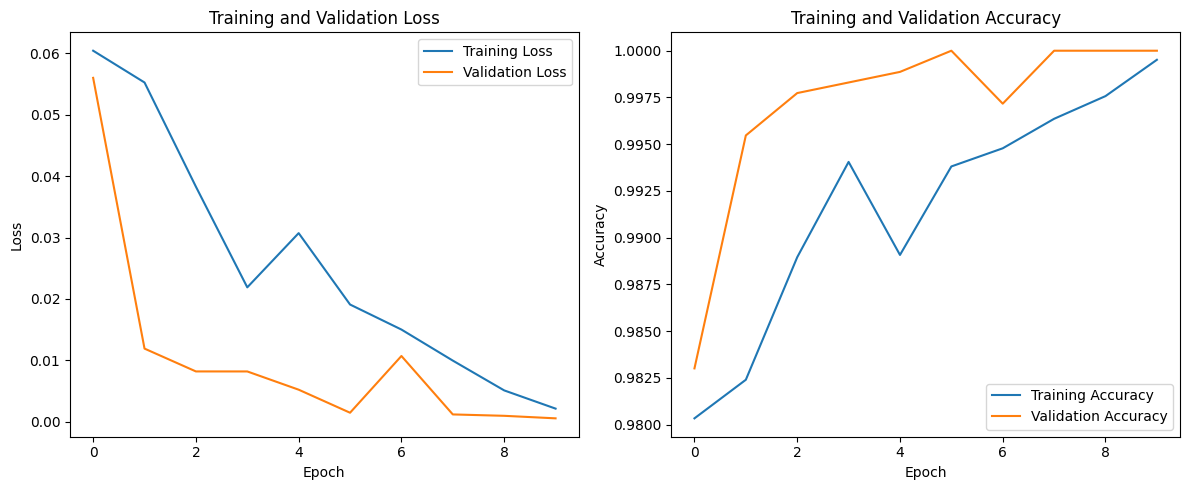

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, train_accs, val_losses, val_accs, num_epochs):
    epochs = range(num_epochs)

    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Training Accuracy')
    plt.plot(epochs, val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Assuming num_epochs was passed to train_model, we can use 10 for now as specified in the call
plot_training_history(train_losses, train_accs, val_losses, val_accs, num_epochs=10)

In [ ]:
import torch

def evaluate_model(model, dataloader, criterion, dataset_size, phase):
    model.eval() # Set model to evaluate mode
    running_loss = 0.0
    running_corrects = 0

    # Iterate over data.
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    total_loss = running_loss / dataset_size
    total_acc = running_corrects.double() / dataset_size

    print(f'{phase} Loss: {total_loss:.4f} Acc: {total_acc:.4f}')
    return total_acc

print("\nEvaluating model on training, validation, and test sets:")
# Evaluate on train set
_ = evaluate_model(model, dataloaders['train'], criterion, dataset_sizes['train'], 'Train')

# Evaluate on validation set
_ = evaluate_model(model, dataloaders['val'], criterion, dataset_sizes['val'], 'Validation')

# Evaluate on test set
_ = evaluate_model(model, dataloaders['test'], criterion, dataset_sizes['test'], 'Test')


Evaluating model on training, validation, and test sets:
Train Loss: 0.0056 Acc: 0.9985
Validation Loss: 0.0015 Acc: 1.0000
Test Loss: 0.0013 Acc: 0.9994


In [ ]:
# Save the trained model
model_save_path = 'densenet_cotton_rice_classifier.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to densenet_cotton_rice_classifier.pth
